In [84]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [56]:
# setup and feature engineering
df = pd.read_csv('../../data/processed/neighborhood_crime_counts.csv')

# set neighborhood as index so removed from feature columns
df.set_index("neighborhood", inplace=True)

# select feature columns
feature_cols = ['avgsocioeconscore', 'avgAccessToCareScore', 'avgMobidityScore', 'mortalityscore', 'avgBuiltEnvScore', 'avgOverallEquityScore', 
                'population_density', 'Percent White', 'Median Household Income', 'Per Capita Income', 
                'program_count_per1000', 'Percent Black','Percent Native American', 'Percent Hispanic', 'Median Home Value',
                'Percent Asian','Percent Hawaiian/Pacific Islander','Percent Other Race','Percent Two or More Races', 'Percent Living in Poverty', 
               'percent_less_hs', 'percent_at_hs', 'percent_some_college','percent_bachelors']
X = df[feature_cols]

# target column - unscaled
target_col = 'crime_per1000'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [57]:
df[target_col].describe()

count      78.000000
mean      683.871890
std       968.995353
min        97.443609
25%       309.324489
50%       411.934134
75%       626.925245
max      7270.095073
Name: crime_per1000, dtype: float64

In [58]:
crime_quantile = int(df[target_col].quantile(.99))
crime_quantile

4695

## statsmodels Summary

In [59]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     1.976
Date:                Thu, 29 May 2025   Prob (F-statistic):             0.0206
Time:                        21:23:44   Log-Likelihood:                -622.70
No. Observations:                  78   AIC:                             1293.
Df Residuals:                      54   BIC:                             1350.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## Linear Regression with L1 Regularization

In [60]:
lasso = Lasso(alpha=10)
lasso.fit(X_scaled, y)

# coefficients
lasso_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)
print(lasso_coef_df)

# model performance
lasso_r2 = r2_score(y, lasso.predict(X_scaled))
lasso_rmse = root_mean_squared_error(y, lasso.predict(X_scaled))

                              Feature  Coefficient
21                      percent_at_hs  -429.302853
1                avgAccessToCareScore  -404.143652
11                      Percent Black   332.906896
3                      mortalityscore   304.627932
2                    avgMobidityScore  -220.053329
4                    avgBuiltEnvScore   166.982982
7                       Percent White  -157.595300
0                   avgsocioeconscore   157.505272
22               percent_some_college   143.437069
17                 Percent Other Race  -137.806837
10              program_count_per1000   136.874587
18          Percent Two or More Races    85.114315
12            Percent Native American    84.740030
9                   Per Capita Income   -73.587601
8             Median Household Income    71.302169
16  Percent Hawaiian/Pacific Islander    66.383889
19          Percent Living in Poverty    40.959605
6                  population_density   -20.725800
13                   Percent Hi

In [61]:
print(lasso_r2)

0.4182801362592231


In [62]:
print(lasso_rmse)

734.3053667966645


## Linear Regression with L2 Regularization

In [63]:
ridge = Ridge(alpha=10)
ridge.fit(X_scaled, y)

# coefficients
ridge_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)
print(ridge_coef_df)

# model performance
ridge_r2 = r2_score(y, ridge.predict(X_scaled))
ridge_rmse = root_mean_squared_error(y, ridge.predict(X))

                              Feature  Coefficient
11                      Percent Black   275.095169
1                avgAccessToCareScore  -266.546942
3                      mortalityscore   224.928187
21                      percent_at_hs  -209.102916
4                    avgBuiltEnvScore   172.041517
22               percent_some_college   148.859668
2                    avgMobidityScore  -135.828558
7                       Percent White  -129.559213
17                 Percent Other Race  -122.710732
10              program_count_per1000   108.976617
18          Percent Two or More Races    99.761708
9                   Per Capita Income   -85.560885
23                  percent_bachelors    74.328997
12            Percent Native American    66.445832
0                   avgsocioeconscore    64.921295
20                    percent_less_hs   -57.773512
8             Median Household Income    52.061573
16  Percent Hawaiian/Pacific Islander    47.913576
6                  population_d

/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


In [64]:
print(ridge_r2)

0.3934128040681839


In [65]:
print(ridge_rmse)

1647284.0078907958


## Linear Regression with Elasticnet Regularization

In [66]:
elastic = ElasticNet(alpha=.1, l1_ratio=0.5)
elastic.fit(X_scaled, y)

# coefficients
elastic_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": elastic.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)
print(elastic_coef_df)

# model performance
elastic_r2 = r2_score(y, elastic.predict(X_scaled))
elastic_rmse = root_mean_squared_error(y, elastic.predict(X))

                              Feature  Coefficient
1                avgAccessToCareScore  -373.557848
21                      percent_at_hs  -335.116420
11                      Percent Black   297.988858
3                      mortalityscore   273.752082
2                    avgMobidityScore  -207.113612
7                       Percent White  -186.530644
22               percent_some_college   178.090729
4                    avgBuiltEnvScore   172.155921
0                   avgsocioeconscore   139.797813
17                 Percent Other Race  -138.382953
10              program_count_per1000   127.731770
23                  percent_bachelors   112.930564
18          Percent Two or More Races   109.946029
9                   Per Capita Income  -107.530474
8             Median Household Income    88.084336
12            Percent Native American    83.651493
19          Percent Living in Poverty    72.555572
16  Percent Hawaiian/Pacific Islander    71.555942
13                   Percent Hi

/Users/uelski/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


In [67]:
print(elastic_r2)

0.4179161642610526


In [68]:
print(elastic_rmse)

14196267.25137373


## Subset of feature columns

In [69]:
feature_cols = ['avgsocioeconscore', 'avgAccessToCareScore', 'avgMobidityScore', 'mortalityscore', 'avgBuiltEnvScore', 
                'population_density', 'Percent White', 'Median Household Income', 'Per Capita Income', 
                'program_count_per1000', 'Percent Black','Percent Native American', 'Percent Hispanic', 'Percent Hawaiian/Pacific Islander','Percent Other Race','Percent Two or More Races', 'Percent Living in Poverty', 
               'percent_less_hs', 'percent_some_college']
X = df[feature_cols]

# target column - unscaled
target_col = 'crime_per1000'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [70]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     1.910
Date:                Thu, 29 May 2025   Prob (F-statistic):             0.0309
Time:                        21:24:12   Log-Likelihood:                -627.57
No. Observations:                  78   AIC:                             1295.
Df Residuals:                      58   BIC:                             1342.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## Dropping DIA - Outlier

In [71]:
df = df[df['crime_per1000'] != df['crime_per1000'].max()]
df.shape

(77, 39)

In [72]:
feature_cols = ['avgsocioeconscore', 'avgAccessToCareScore', 'avgMobidityScore', 'mortalityscore', 'avgBuiltEnvScore', 
                'population_density', 'Percent White', 'Median Household Income', 'Per Capita Income', 
                'program_count_per1000', 'Percent Black','Percent Native American', 'Percent Hispanic', 'Percent Hawaiian/Pacific Islander','Percent Other Race','Percent Two or More Races', 'Percent Living in Poverty', 
               'percent_less_hs', 'percent_some_college']
X = df[feature_cols]

# target column - unscaled
target_col = 'crime_per1000'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [73]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     3.430
Date:                Thu, 29 May 2025   Prob (F-statistic):           0.000163
Time:                        21:24:20   Log-Likelihood:                -573.34
No. Observations:                  77   AIC:                             1187.
Df Residuals:                      57   BIC:                             1234.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## Simplifying the Model Further

In [78]:
feature_cols = ['avgAccessToCareScore', 'mortalityscore', 'Median Household Income', 'Per Capita Income' ]
X = df[feature_cols]

# target column - unscaled
target_col = 'crime_per1000'
y = df[target_col].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale full X
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [79]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_const = sm.add_constant(X_scaled_df)

model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     2.333
Date:                Thu, 29 May 2025   Prob (F-statistic):             0.0638
Time:                        21:32:44   Log-Likelihood:                -598.01
No. Observations:                  77   AIC:                             1206.
Df Residuals:                      72   BIC:                             1218.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Hyperparameter Tuning

In [81]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0]}
grid_search = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5)
grid_search.fit(X_scaled, y)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'alpha': 1.0}
Best score: -1.2342836529487546


In [83]:
lasso = Lasso(alpha=1)
lasso.fit(X_scaled, y)

# coefficients
lasso_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)
print(lasso_coef_df)

# model performance
lasso_r2 = r2_score(y, lasso.predict(X_scaled))
lasso_rmse = root_mean_squared_error(y, lasso.predict(X_scaled))

                   Feature  Coefficient
0     avgAccessToCareScore  -299.448261
1           mortalityscore   115.447774
2  Median Household Income    96.298321
3        Per Capita Income    64.660419


## Plots

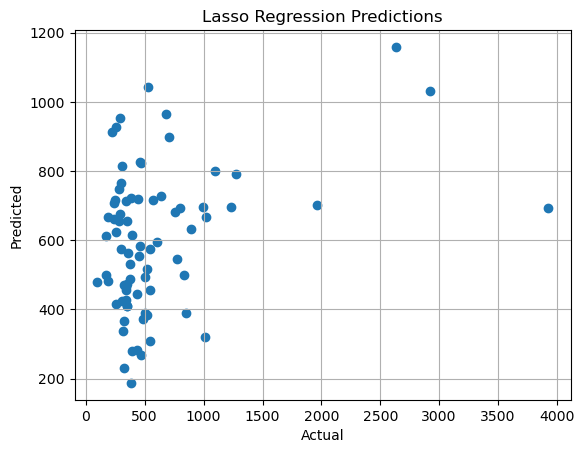

In [86]:
y_pred = lasso.predict(X_scaled)
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression Predictions")
plt.grid(True)
plt.show()

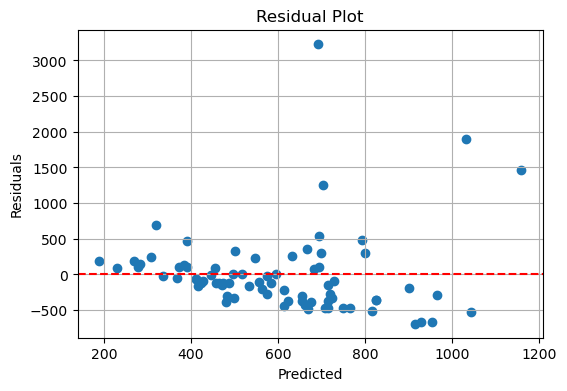

In [87]:
residuals = y - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()